# AULA 1: Conceitos de séries temporais
## Insper - PADS
### Financial Analytics
#### Autor: Paloma Vaissman Uribe

### 1. Revisão de variável aleatória: gerando uma uniforme discreta para o experimento de jogar um dado

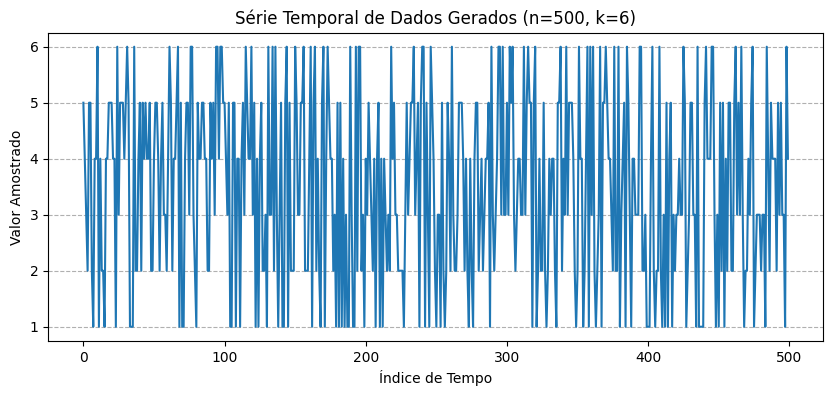

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo o número de simulações
n = 500

# 2. Definindo a função 'dados' (amostragem com substituição)
def dados(n, k):
    """
    Gera uma amostra de 'n' pontos de dados,
    escolhidos de 1 a 'k' com reposição.
    """
    return np.random.randint(1, k + 1, size=n)

# 3. Gerando os dados e plotando
dados_gerados = dados(n, 6)

plt.figure(figsize=(10, 4)) # Define o tamanho da figura
plt.plot(dados_gerados)
plt.title(f'Série Temporal de Dados Gerados (n={n}, k=6)')
plt.xlabel('Índice de Tempo')
plt.ylabel('Valor Amostrado')
plt.grid(axis='y', linestyle='--')
plt.show()

### 2. Defasagem e diferenciação: Python code

In [15]:
# Usando dados de PIB do BCB

import pandas as pd
from bcb import sgs

# 1. Parâmetros e Download de Dados
data_inicio = "2003-01-01"
CODIGO_IBCBR_REAL = 24364  # IBC-Br Dessazonalizado (proxy do PIB Real)

# Baixa a série IBC-Br e armazena no DataFrame com o nome de coluna 'pib_original'
ibcbr_real = sgs.get({'pib_original': CODIGO_IBCBR_REAL}, start=data_inicio)

# 2. Criação das Variáveis Diferenciada e Defasada (Usando Pandas)

# Diferenciação (pib_diff): Y(t) - Y(t-1)
# O método .diff(1) insere automaticamente NaN no primeiro valor.
ibcbr_real['pib_diff'] = ibcbr_real['pib_original'].diff(periods=1)

# Defasagem (pib_lag): Y(t-1)
# O método .shift(1) move o valor Y(t-1) para o tempo t.
ibcbr_real['pib_lag'] = ibcbr_real['pib_original'].shift(periods=1)

# O DataFrame 'ibcbr_real' (que corresponde ao 'data' do R) está completo.

# 3. Visualização do Dataset Final (Equivalente a head(data))
print(ibcbr_real.head())

            pib_original  pib_diff   pib_lag
Date                                        
2003-01-01      70.53904       NaN       NaN
2003-02-01      71.71545   1.17641  70.53904
2003-03-01      71.36498  -0.35047  71.71545
2003-04-01      70.87144  -0.49354  71.36498
2003-05-01      70.16235  -0.70909  70.87144


### 3. Função de autocorrelação e simulação de processos

Text(0, 0.5, 'Autocorrelação')

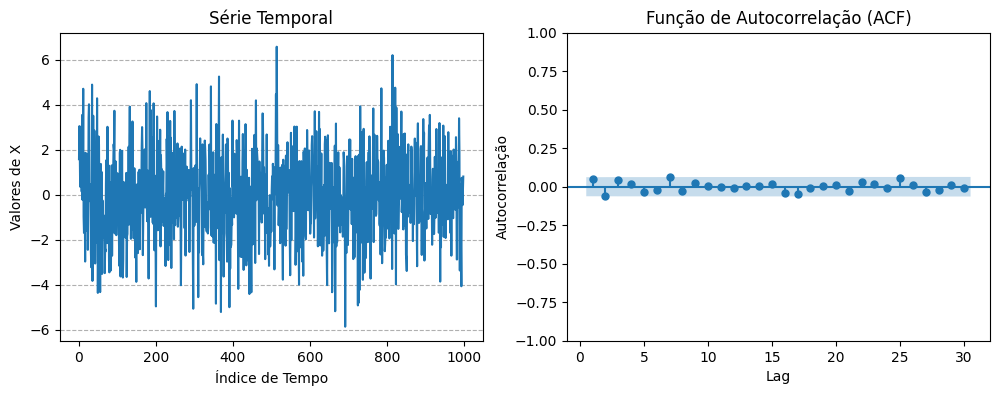

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm

# 1. Geração de Dados (Usando scipy.stats.norm)
X = norm.rvs(loc=0, scale=2, size=1000)

# 2. Configuração do Layout do Gráfico (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3. Plotagem da Série Temporal
axes[0].plot(X)
axes[0].set_title('Série Temporal')
axes[0].set_xlabel('Índice de Tempo')
axes[0].set_ylabel('Valores de X')
axes[0].grid(axis='y', linestyle='--')

# 4. Plotagem da ACF (Função de Autocorrelação)
plot_acf(X,
  ax=axes[1],
  title='Função de Autocorrelação (ACF)',
  zero=False)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelação')


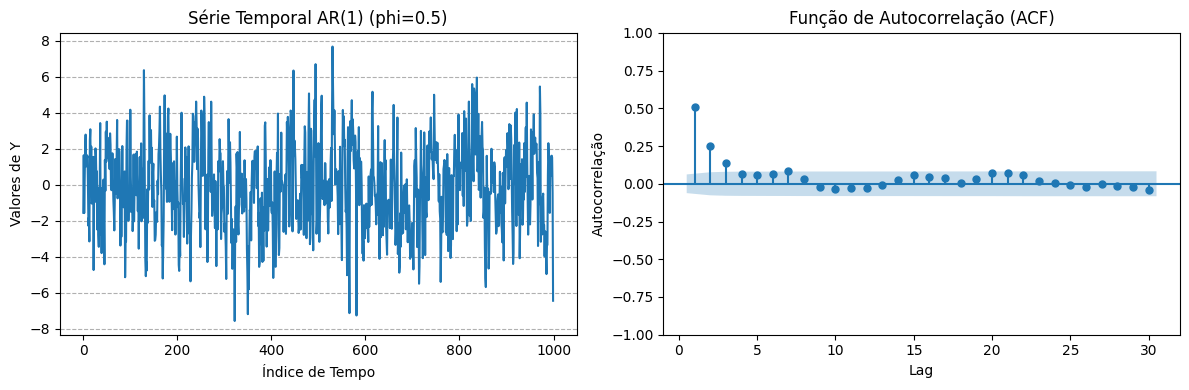

In [24]:
# 1. Parâmetros
phi = 0.5  # Parâmetro AR(1) (phi)
n = 1000   # Número de observações
e = np.random.normal(loc=0, scale=2, size=n)

# 2. Simulação da Série Temporal AR(1)
y = np.zeros(n)
y[0] = e[0]
for i in range(1, n):
    y[i] = phi * y[i-1] + e[i]

# 3. Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(y)
axes[0].set_title(f'Série Temporal AR(1) (phi={phi})')
axes[0].set_xlabel('Índice de Tempo')
axes[0].set_ylabel('Valores de Y')
axes[0].grid(axis='y', linestyle='--')

plot_acf(y,
  ax=axes[1],
  title='Função de Autocorrelação (ACF)',
  zero=False)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelação')

plt.tight_layout()
plt.show()

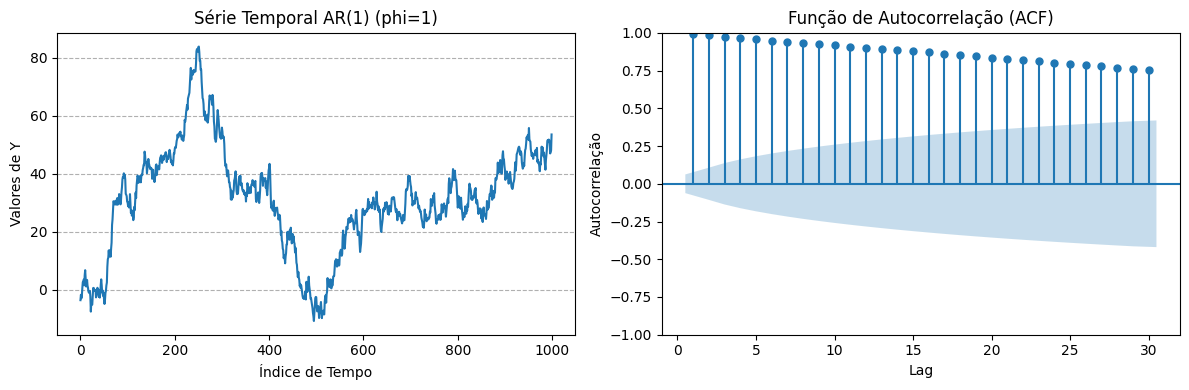

In [26]:
# 1. Parâmetros
phi = 1  # Parâmetro PASSEIO ALEATÓRIO
n = 1000   # Número de observações
e = np.random.normal(loc=0, scale=2, size=n)

# 2. Simulação da Série Temporal AR(1)
y = np.zeros(n)
y[0] = e[0]
for i in range(1, n):
    y[i] = phi * y[i-1] + e[i]

# 3. Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(y)
axes[0].set_title(f'Série Temporal AR(1) (phi={phi})')
axes[0].set_xlabel('Índice de Tempo')
axes[0].set_ylabel('Valores de Y')
axes[0].grid(axis='y', linestyle='--')

plot_acf(y,
  ax=axes[1],
  title='Função de Autocorrelação (ACF)',
  zero=False)
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelação')

plt.tight_layout()
plt.show()

### 4. Componentes de uma série

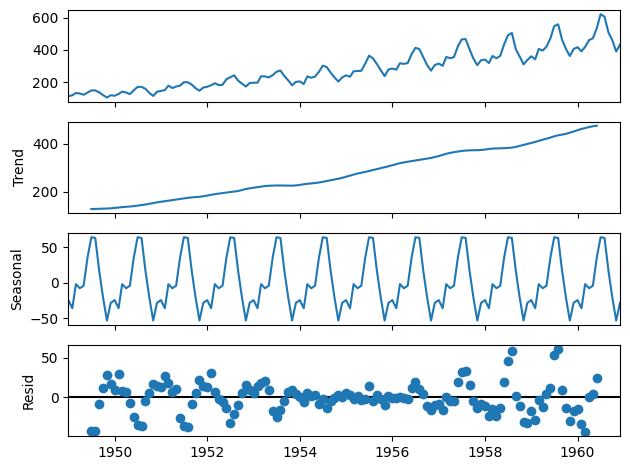

In [27]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Dados de AirPassengers
data_r = sm.datasets.get_rdataset(
  dataname="AirPassengers",
  package="datasets")
AP = pd.Series(data_r.data["value"].values,
               index=pd.date_range(start="1949-01-01",
               periods=len(data_r.data), freq="MS"))

# 2. Decomposição Sazonal
decomposeAP = seasonal_decompose(
  AP,
  model="additive", #alt: multiplicative
  period=12)
decomposeAP.plot()

# Exibir o gráfico
plt.show()

### 5. Prophet: outra forma de estimar componentes sazonais

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpofr_dk25/28byvshb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpofr_dk25/k9bnm1l1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65393', 'data', 'file=/tmp/tmpofr_dk25/28byvshb.json', 'init=/tmp/tmpofr_dk25/k9bnm1l1.json', 'output', 'file=/tmp/tmpofr_dk25/prophet_modelws57bkkd/prophet_model-20251010171508.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:15:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:15:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


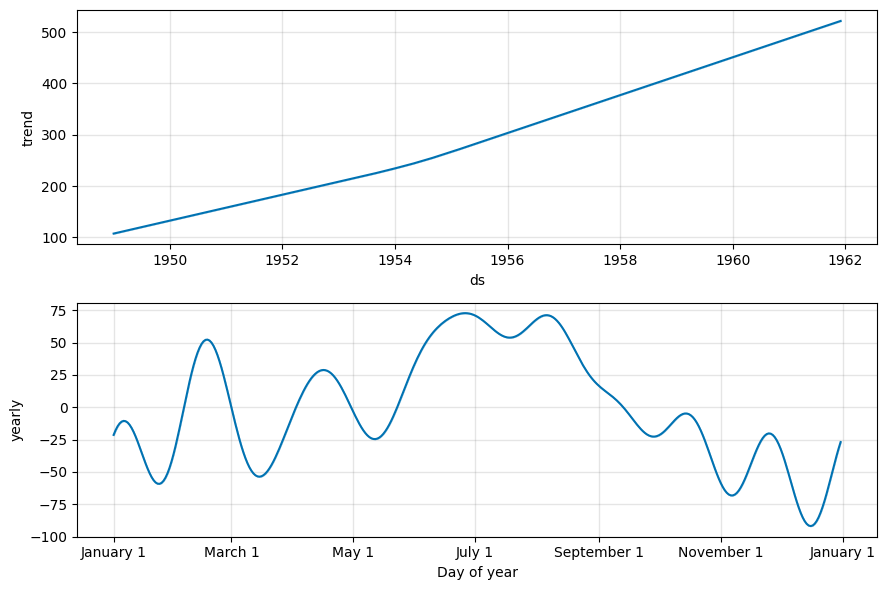

In [28]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from prophet import Prophet
from prophet.plot import plot_components

data_r = sm.datasets.get_rdataset(
  dataname="AirPassengers", package="datasets")
AP_series = pd.Series(
    data_r.data["value"].values,
    index=pd.date_range(start="1949-01-01",
    periods=len(data_r.data), freq="MS"))
df = AP_series.reset_index()
df.columns = ['ds', 'y']

m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=12, freq='MS')
forecast = m.predict(future)
fig_components = plot_components(m, forecast)
plt.show()

In [29]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.406338,56.356143,116.968458,107.406338,107.406338,-21.387455,-21.387455,-21.387455,-21.387455,-21.387455,-21.387455,0.0,0.0,0.0,86.018883
1,1949-02-01,109.550561,50.399179,108.942538,109.550561,109.550561,-30.055335,-30.055335,-30.055335,-30.055335,-30.055335,-30.055335,0.0,0.0,0.0,79.495226
2,1949-03-01,111.487279,81.769040,140.098541,111.487279,111.487279,-0.461698,-0.461698,-0.461698,-0.461698,-0.461698,-0.461698,0.0,0.0,0.0,111.025581
3,1949-04-01,113.631502,80.860394,137.057427,113.631502,113.631502,-4.912485,-4.912485,-4.912485,-4.912485,-4.912485,-4.912485,0.0,0.0,0.0,108.719017
4,1949-05-01,115.706556,84.384871,140.095194,115.706556,115.706556,-3.611275,-3.611275,-3.611275,-3.611275,-3.611275,-3.611275,0.0,0.0,0.0,112.095281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1961-08-01,509.384228,548.657750,605.971277,509.075824,509.677316,68.199423,68.199423,68.199423,68.199423,68.199423,68.199423,0.0,0.0,0.0,577.583651
152,1961-09-01,512.515877,501.107321,556.141370,512.140578,512.870399,16.508617,16.508617,16.508617,16.508617,16.508617,16.508617,0.0,0.0,0.0,529.024494
153,1961-10-01,515.546505,466.752694,523.591381,515.111071,515.979982,-21.678872,-21.678872,-21.678872,-21.678872,-21.678872,-21.678872,0.0,0.0,0.0,493.867634
154,1961-11-01,518.678155,431.053298,487.798180,518.166608,519.193143,-58.662400,-58.662400,-58.662400,-58.662400,-58.662400,-58.662400,0.0,0.0,0.0,460.015755


### 6. Teste ADF

In [31]:
ibcbr_real

,pib_original,pib_diff,pib_lag
Date,,,
2003-01-01,70.53904,NaN,NaN
2003-02-01,71.71545,1.17641,70.53904
2003-03-01,71.36498,-0.35047,71.71545
2003-04-01,70.87144,-0.49354,71.36498
2003-05-01,70.16235,-0.70909,70.87144
...,...,...,...
2025-03-01,109.76296,0.74746,109.01550
2025-04-01,110.24525,0.48229,109.76296
2025-05-01,108.95406,-1.29119,110.24525


In [34]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

gdp = ibcbr_real['pib_original']
k_calculado = np.floor((len(gdp) - 1)**(1/3)).astype(int)

resultado_adf = adfuller(
    gdp,
    maxlag=k_calculado,
    autolag=None, # Desativa a seleção automática do k
    regression='c' # Padrão para testar estacionariedade
)

print("=== Resultados do Teste Aumentado de Dickey-Fuller (ADF) ===")
print(f"Estatística de Teste ADF: {resultado_adf[0]:.4f}")
print(f"Valor p (P-value): {resultado_adf[1]:.4f}")
print(f"Número de Defasagens (Lags): {resultado_adf[2]}")
print("Valores Críticos:")
for key, value in resultado_adf[4].items():
    print(f"  {key}: {value:.4f}")

=== Resultados do Teste Aumentado de Dickey-Fuller (ADF) ===
Estatística de Teste ADF: -2.2502
Valor p (P-value): 0.1885
Número de Defasagens (Lags): 6
Valores Críticos:
  1%: -3.4554
  5%: -2.8726
  10%: -2.5726


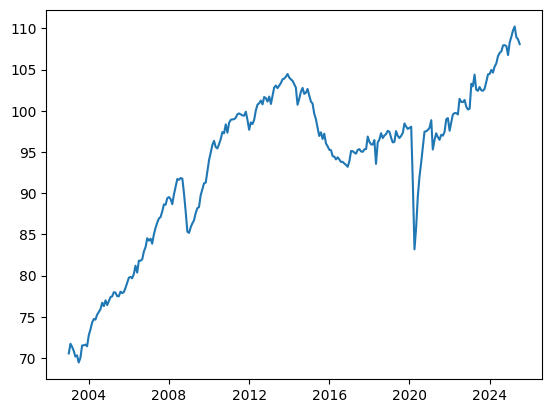

In [36]:
plt.plot(ibcbr_real['pib_original'])